In [1]:
import pandas as pd
import numpy as np

num_months = 12
start_date = '2023-01-01'
product_id = 'P101'
initial_sales = 120
growth_per_month = 20

dates = pd.date_range(start=start_date, periods=num_months, freq='MS')


sales = [initial_sales + (growth_per_month * i) + np.random.randint(-5, 5)
         for i in range(num_months)]


df = pd.DataFrame({
    'date': dates.strftime('%Y-%m-%d'),
    'product_id': [product_id] * num_months,
    'sales': sales
})


df.to_csv('sales_data.csv', index=False)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
         date product_id  sales
0  2023-01-01       P101    116
1  2023-02-01       P101    143
2  2023-03-01       P101    160
3  2023-04-01       P101    175
4  2023-05-01       P101    199


In [2]:
df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

df.head()

,date,product_id,sales
0,2023-01-01,P101,116
1,2023-02-01,P101,143
2,2023-03-01,P101,160
3,2023-04-01,P101,175
4,2023-05-01,P101,199


In [3]:
from prophet import Prophet

forecast_df = df.rename(columns={
    'date':'ds',
    'sales':'y'
})

model = Prophet()

model.fit(forecast_df)

future = model.make_future_dataframe(periods=6, freq='M')

forecast = model.predict(future)

forecast[['ds','yhat']].tail()

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 8.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat
13,2024-01-31,379.812767
14,2024-02-29,398.704955
15,2024-03-31,418.900053
16,2024-04-30,438.443696
17,2024-05-31,458.638793


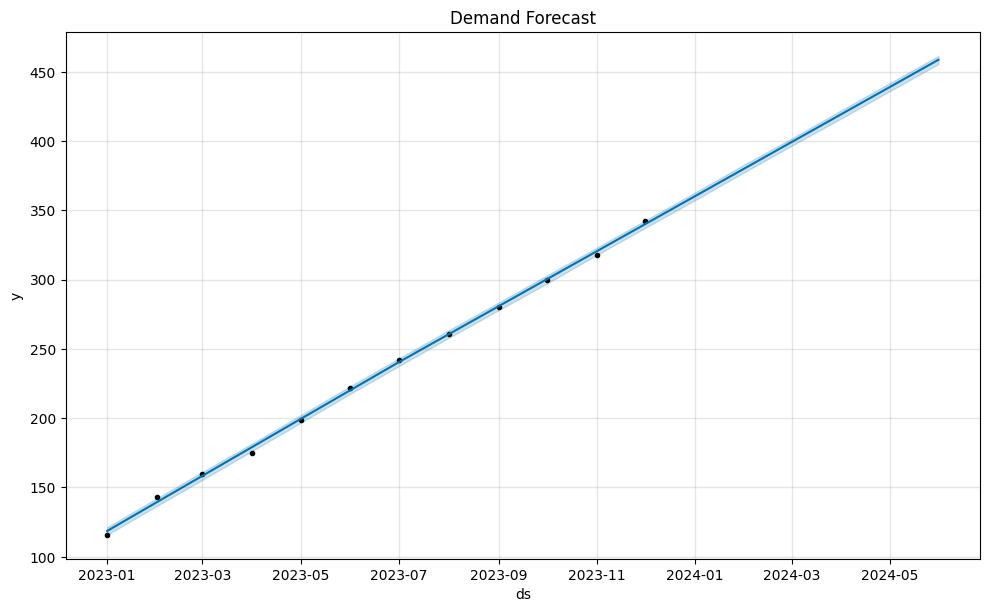

In [4]:
import matplotlib.pyplot as plt

model.plot(forecast)

plt.title("Demand Forecast")

plt.show()

In [5]:
import numpy as np

annual_demand = df['sales'].sum()

ordering_cost = 50

holding_cost = 2

EOQ = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print("Economic Order Quantity:", EOQ)

Economic Order Quantity: 371.34889255254285


In [6]:
daily_demand = annual_demand / 365

lead_time = 7

reorder_point = daily_demand * lead_time

print("Reorder Point:", reorder_point)

Reorder Point: 52.893150684931506


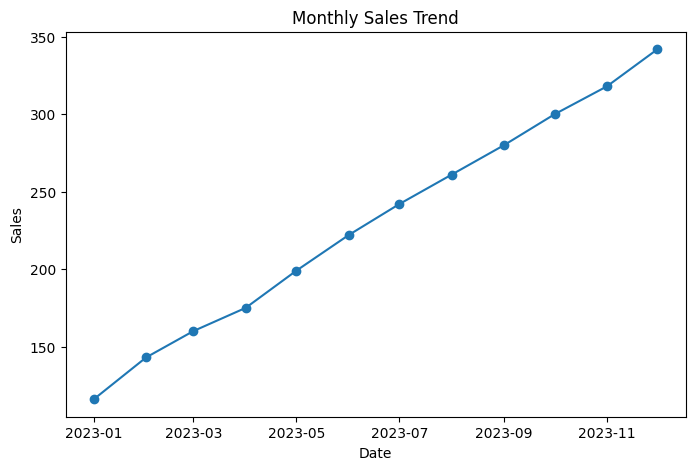

In [7]:
plt.figure(figsize=(8,5))

plt.plot(df['date'], df['sales'], marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()